In [39]:
# Importacion de librerias
import os # para manejar rutas de archivos
import jax
import kagglehub # para descargar el dataset
import pandas as pd # para el manejo de datos
import jax.numpy as jnp # para el manejo de datos con jax
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split # para dividir el dataset
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix # para evaluar el modelo de clasificacion
import seaborn as sns # para visualizar las matrices de confusión

In [40]:
# cargo de dataset y EDA
path = kagglehub.dataset_download("fedesoriano/stroke-prediction-dataset")
df = pd.read_csv(os.path.join(path, "healthcare-dataset-stroke-data.csv"))

In [41]:
print("\n Datos Iniciales")
display(df.head())


 Datos Iniciales


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [42]:
print(f"\n tamaño del Dataset {df.shape}")


 tamaño del Dataset (5110, 12)


In [43]:
print("Tipos de datos")
df.info()

Tipos de datos
<class 'pandas.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   str    
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   str    
 6   work_type          5110 non-null   str    
 7   Residence_type     5110 non-null   str    
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   str    
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), str(5)
memory usage: 479.2 KB


In [44]:
print("\nDescripcion del Dataset ")
display(df.describe().round(2))



Descripcion del Dataset 


,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.00,5110.00,5110.0,5110.00,5110.00,4909.00,5110.00
mean,36517.83,43.23,0.1,0.05,106.15,28.89,0.05
std,21161.72,22.61,0.3,0.23,45.28,7.85,0.22
min,67.00,0.08,0.0,0.00,55.12,10.30,0.00
25%,17741.25,25.00,0.0,0.00,77.24,23.50,0.00
50%,36932.00,45.00,0.0,0.00,91.88,28.10,0.00
75%,54682.00,61.00,0.0,0.00,114.09,33.10,0.00
max,72940.00,82.00,1.0,1.00,271.74,97.60,1.00


### Deteccion de valores aberrantes en variables numericas (Gráfica de caja y bigotes)



Variables numericas analizadas: 3
['age', 'avg_glucose_level', 'bmi']


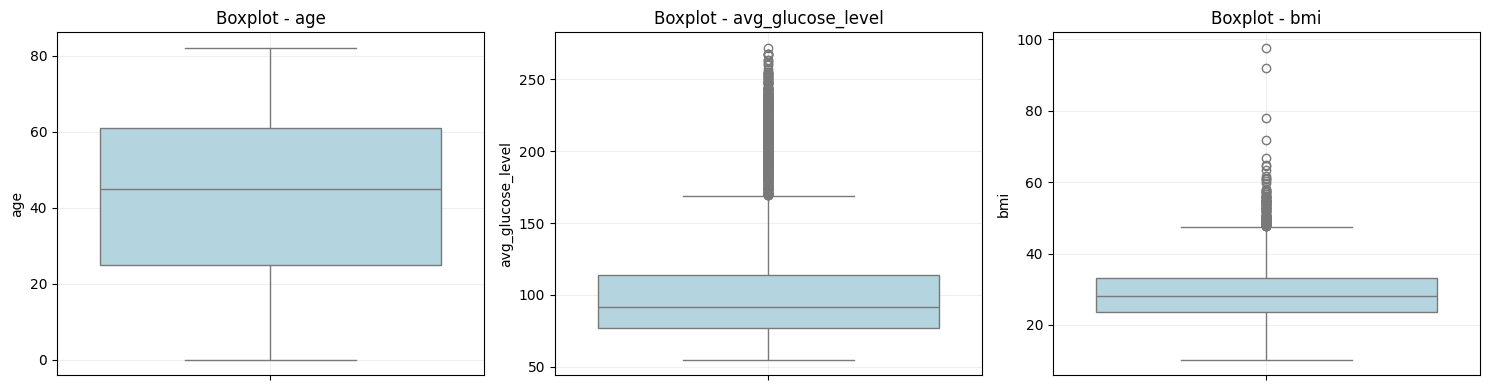

In [45]:
numeric_cols = df.select_dtypes(include=['float64']).columns.tolist()
numeric_cols_no_target = [col for col in numeric_cols if col != target_col] if 'target_col' in locals() else [c for c in numeric_cols if c != 'stroke']

print(f"\nVariables numericas analizadas: {len(numeric_cols_no_target)}")
print(numeric_cols_no_target)

if numeric_cols_no_target:
    n_cols = 3
    n_rows = (len(numeric_cols_no_target) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
    axes = axes.flatten()

    for idx, col in enumerate(numeric_cols_no_target):
        sns.boxplot(y=df[col], ax=axes[idx], color='lightblue')
        axes[idx].set_title(f'Boxplot - {col}')
        axes[idx].set_xlabel('')
        axes[idx].grid(alpha=0.2)

    for idx in range(len(numeric_cols_no_target), len(axes)):
        fig.delaxes(axes[idx])

    plt.tight_layout()
    plt.show()
else:
    print("No se encontraron variables numericas para analizar outliers.")



Variables numéricas analizadas: 3
['age', 'avg_glucose_level', 'bmi']


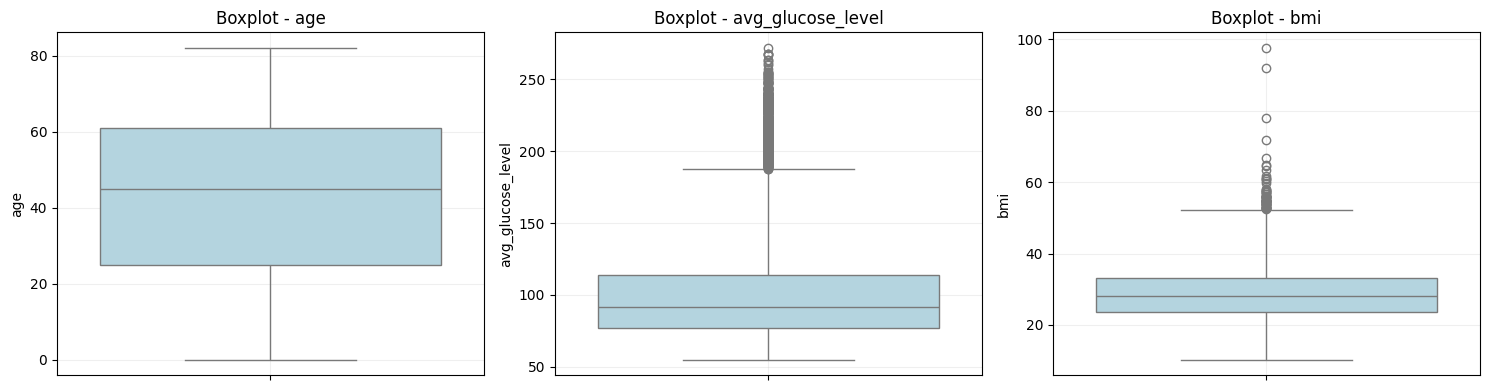

In [46]:
def plot_boxplots(df, target_col='stroke'):
    """
    Identifica las variables numéricas en el DataFrame (excluyendo la variable objetivo)
    y genera boxplots para analizar visualmente la presencia de valores atípicos.
    """
    numeric_cols = df.select_dtypes(include=['float64']).columns.tolist()
    
    if target_col in df.columns:
        numeric_cols_no_target = [col for col in numeric_cols if col != target_col]
    else:
        # Por si se proporciona un dataset sin la variable objetivo
        numeric_cols_no_target = numeric_cols

    print(f"\nVariables numéricas analizadas: {len(numeric_cols_no_target)}")
    print(numeric_cols_no_target)

    if numeric_cols_no_target:
        n_cols = 3
        # Calculamos la cantidad de filas necesarias para nuestra cuadrícula de subplots
        n_rows = (len(numeric_cols_no_target) + n_cols - 1) // n_cols
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
        
        # Aplanamos los ejes para manejarlos fácilmente en un solo bucle iterativo
        if n_rows * n_cols > 1:
            axes = axes.flatten()
        else:
            axes = [axes] # En caso de que haya una sola gráfica

        for idx, col in enumerate(numeric_cols_no_target):
            sns.boxplot(y=df[col], 
                        ax=axes[idx], 
                        whis=2, # aumentamos a 2 veces el IQR para detectar valores aberrantes
                        color='lightblue')
            axes[idx].set_title(f'Boxplot - {col}')
            axes[idx].set_xlabel('')
            axes[idx].grid(alpha=0.2)

        # Eliminamos los subplots sobrantes o vacíos si los hay
        for idx in range(len(numeric_cols_no_target), len(axes)):
            fig.delaxes(axes[idx])

        plt.tight_layout()
        plt.show()
    else:
        print("No se encontraron variables numéricas para analizar outliers.")

# Llamada inicial antes o después de la remoción de outliers:
plot_boxplots(df, target_col='stroke')


In [47]:
# Eliminar valores atípicos de bmi > 55
# Retenemos también los valores nulos para no perderlos antes de la imputación
df = df[(df['bmi'] <= 55) | (df['bmi'].isna())]
print(f"Tamaño del dataset después de eliminar valores atípicos de bmi: {df.shape}")

Tamaño del dataset después de eliminar valores atípicos de bmi: (5077, 12)



Variables numéricas analizadas: 3
['age', 'avg_glucose_level', 'bmi']


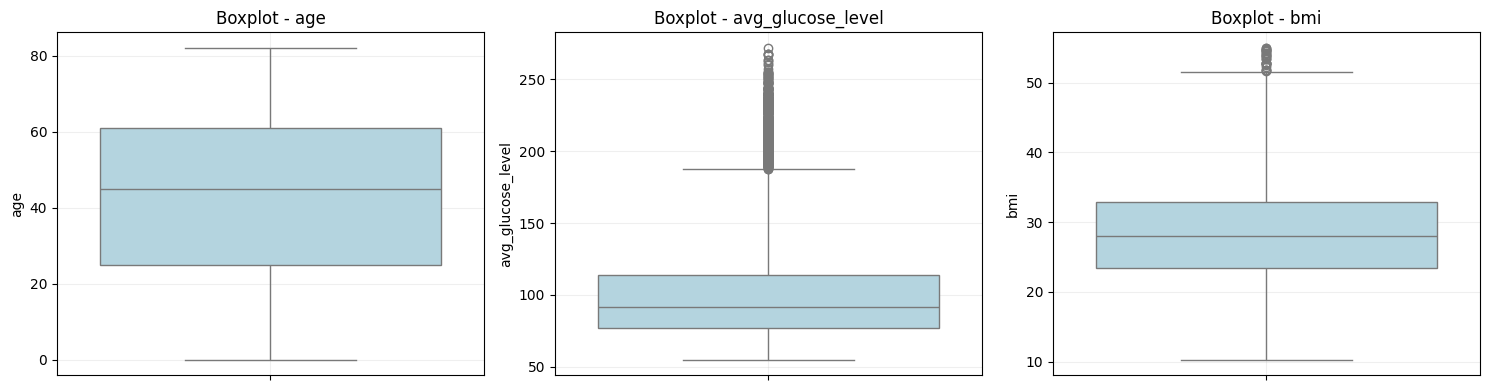

In [48]:
plot_boxplots(df, target_col='stroke')


-Revision de valores faltantes


,Faltantes conteo,Faltantes %
bmi,201,3.96
id,0,0.00
age,0,0.00
gender,0,0.00
hypertension,0,0.00
heart_disease,0,0.00
work_type,0,0.00
ever_married,0,0.00
Residence_type,0,0.00
avg_glucose_level,0,0.00



Balance de la columna objetivo correspondiente a si el paciente tendrá un derrame (Stroke)
Proporciones:
 stroke
0    95.1
1     4.9
Name: proportion, dtype: float64

Conteos:
 stroke
0    4829
1     248
Name: count, dtype: int64


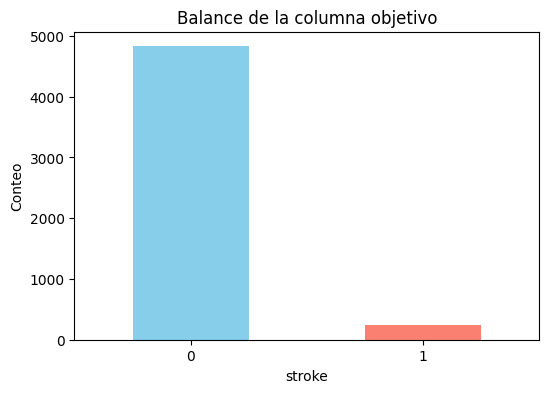

In [49]:
print("\n-Revision de valores faltantes")
missing_data = pd.DataFrame({
    'Faltantes conteo': df.isna().sum(),
    'Faltantes %': (df.isnull().sum() / len(df)) * 1e2
}).sort_values(by='Faltantes conteo', ascending=False) # los ordenamos en orden descendente para ver primero los que tienen mas faltantes
display(missing_data.round(2))

print("\nBalance de la columna objetivo correspondiente a si el paciente tendrá un derrame (Stroke)")
target_col = 'stroke' # la columna objetivo
print("Proporciones:\n", df[target_col].value_counts(normalize=True).round(3) * 100)
print("\nConteos:\n", df[target_col].value_counts())

# Graficando el balance de la columna objetivo
plt.figure(figsize=(6, 4))
df[target_col].value_counts().plot(kind='bar', color=['skyblue', 'salmon']) # el color es para diferencia esta clasificacion binaria
plt.title('Balance de la columna objetivo')
plt.xlabel(target_col)
plt.ylabel('Conteo')
plt.xticks(rotation=0)
plt.show()


Como está muy desbalanceado, al momento de hacer nuestra division de datos, vamos a usar la tecnica de estratificacion para asegurarnos que tanto el conjunto de entrenamiento como el de prueba tengan una representacion proporcional de ambas clases (stroke = 0 y stroke = 1).
Asimismo, dado que el dataset tiene una cantidad limitada de muestras, vamos a usar la tecnica de validacion cruzada para evaluar nuestro modelo de manera mas robusta y evitar problemas de sobreajuste.
Lo más importante de nuestro modelo es evitar los falsos negativos (FN), es decir, casos donde el modelo predice que un paciente no tendrá un derrame (stroke = 0) cuando en realidad sí lo tendrá (stroke = 1). Esto es crucial porque un falso negativo podría llevar a la falta de atención médica necesaria para un paciente que realmente está en riesgo de sufrir un derrame. Por lo tanto, vamos a enfocarnos en maximizar el recall (sensibilidad) de nuestro modelo, ya que esta métrica nos indica qué tan bien el modelo identifica correctamente los casos positivos (stroke = 1). Sin embargo, también debemos tener en cuenta el precision para evitar demasiados falsos positivos (FP), donde el modelo predice que un paciente tendrá un derrame cuando en realidad no lo tendrá. Por eso, utilizaremos el F1-score como una métrica balanceada que considera tanto el precision como el recall.

Métricas importantes:

F1-score:

$F1-score= 2 \cdot \frac{Precision \cdot Recall}{Precision + Recall}$

Precision:

$Precision = \frac{TP}{TP + FP}$

Recall:

$Recall = \frac{TP}{TP + FN}$

Donde:

TP (True Positives): Verdaderos positivos, el número de casos correctamente predichos como positivos (stroke = 1).
FP (False Positives): Falsos positivos, el número de casos incorrectamente predichos como positivos (stroke = 1 cuando en realidad es 0).
FN (False Negatives): Falsos negativos, el número de casos incorrectamente predichos como negativos (stroke = 0 cuando en realidad es 1).

In [50]:
class DataPreprocessor:
    def __init__(self, umbral=0.5):
        self.umbral = umbral
        self.mu_x, self.sigma_x = None, None

    def prepare_data(self, df, target_col, test_size=0.2, random_state=42):
        X = df.drop(columns=[target_col])
        y = df[target_col].values.reshape(-1, 1) # con reshape(-1, 1) convertimos el vector de etiquetas a una matriz de una sola columna

        X_encoded = pd.get_dummies(X, drop_first=True, dtype=float) # drop_first=True para evitar la multicolinealidad, dtype=float para asegurar que los datos sean de tipo float, get_dummies sirve para pasar las variables categoricas a numericas

        self.mu_x, self.sigma_x = X_encoded.mean().values, X_encoded.std().values #obtenemos la media y la desviacion estandar de cada columna, esto es necesario para la normalizacion de los datos
        self.sigma_x = jnp.where(self.sigma_x == 0, 1.0, self.sigma_x)
        X_norm = (X_encoded.values - self.mu_x) / self.sigma_x # usamos where para evitar la division por cero en caso de que alguna columna tenga desviacion estandar igual a cero, esto es importante para evitar errores en la normalizacion

        y_array = jnp.array(y, dtype=jnp.float32)

        ones = jnp.ones((X_norm.shape[0], 1), dtype=jnp.float32)
        X_b = jnp.hstack([X_norm, ones]) # agregamos una columna de unos al final de X_norm para representar el termino de sesgo (bias) en nuestro modelo lineal, esto es importante para que el modelo pueda aprender un umbral de decision que no sea necesariamente cero, el termino de sesgo permite que la frontera de decision del modelo no tenga que pasar por el origen (0,0) y pueda ajustarse mejor a los datos, esto es especialmente importante en problemas de clasificacion donde las clases pueden no estar separadas por una linea que pase por el origen.

        return train_test_split(X_b, y_array,
                                test_size=test_size,
                                stratify=y_array, random_state=random_state)


In [51]:
# Regresión Lineal
class LinearRegressionJAX:
    def __init__(self, preprocessor):
        self.theta = None
        self.preprocessor = preprocessor # el preprocesador es necesario para poder normalizar los datos de entrada antes de hacer las predicciones, esto es importante porque el modelo fue entrenado con datos normalizados, si no normalizamos los datos de entrada antes de hacer las predicciones, el modelo no funcionará correctamente y las predicciones serán incorrectas.

    def train(self, X_train, y_train):
        XT = X_train.T
        self.theta = jnp.linalg.solve(jnp.dot(XT, X_train), jnp.dot(XT, y_train)) # esta es la ecuacion normal para resolver el problema de minimos cuadrados en regresion lineal,nos da los coeficientes optimos (theta) que minimizan la funcion de costo de minimos cuadrados,al tomar la derivada de la funcion de costo con respecto a theta e igualarla a cero para encontrar el minimo, eficiente para conjuntos de datos pequeños a medianos, pero puede ser computacionalmente costosa para conjuntos de datos muy grandes debido a la inversion de matrices, sin embargo, en este caso nuestro dataset es pequeño

    def predict(self, X_data):
        y_pred = jnp.dot(X_data, self.theta)
        return y_pred

In [52]:
@jax.jit # esta decoracion de jax.jit compila la funcion para que se ejecute de manera mas eficiente, importante en el caso de la regresion logistica donde se realizan muchas iteraciones de entrenamiento y calculo de gradientes, al compilar la funcion con jax.jit, podemos acelerar significativamente el proceso de entrenamiento y hacer que el modelo sea mas rapido y eficiente.
def sigmoid(z):
    return 1.0 / (1.0 + jnp.exp(-z)) # esta es la funcion sigmoide, que es la funcion de activacion utilizada en la regresion logistica para mapear las predicciones lineales a un rango entre 0 y 1.

def compute_weighted_bce_loss(theta, X, y, pos_weight):
    predictions = sigmoid(jnp.dot(X, theta)) # aplicamos la funcion de sigmoide a la multiplicacion de X por theta para obtener las probabilidades predichas por el modelo, esto es necesario porque la funcion de costo de entropia cruzada binaria (BCE) se calcula en base a las probabilidades predichas por el modelo, y la funcion sigmoide nos permite convertir las predicciones lineales a probabilidades entre 0 y 1, lo cual es esencial para calcular correctamente la perdida de BCE.
    epsilon = 1e-15 # usamos un valor muy cercano a cero para evitar problemas de logaritmo de cero en el calculo de la perdida, esto porque si las predicciones son exactamente 0 o 1, el logaritmo de estas predicciones puede ser indefinido, lo que resultaria en NaN
    loss = -jnp.mean(pos_weight * y * jnp.log(predictions + epsilon) + 1.0 * (1 - y) * jnp.log(1 - predictions + epsilon)) # la pérdida ponderdada donde pos_weight solo multiplica al error cuando y=1, esto es porque queremos minimizar los falsos negativos. Añadimos epsilon a las predicciones.
    return loss

@jax.jit
def update_step_weighted(theta, X, y, learning_rate, pos_weight):
    loss, gradients = jax.value_and_grad(compute_weighted_bce_loss)(theta, X, y, pos_weight) #con el metodo value_and_grad de jax, podemos calcular tanto la perdida como los gradientes, lo que sirve para el proceso de entrenamiento del modelo de regresion logistica, ya que necesitamos calcular la perdida para evaluar el rendimiento del modelo y los gradientes para actualizar los pesos (theta) del modelo en cada iteracion de entrenamiento.
    new_theta = theta - learning_rate * gradients # acá actualizamos multiplicando por el learning_rate para controlar la magnitud de la actualización, esto es importante para asegurar que el modelo converja de manera estable hacia los pesos óptimos, evitando actualizaciones demasiado grandes que podrían hacer que el modelo diverja o actualizaciones demasiado pequeñas que podrían hacer que el proceso de entrenamiento sea muy lento.
    return new_theta, loss

class LogisticRegressionJAX:
    def __init__(self, preprocessor, learning_rate=0.1, epochs=1000):
        self.preprocessor = preprocessor
        self.learning_rate = learning_rate
        self.epochs = epochs # numero de iteraciones de entrenamiento, las veces que vamos a actualizar los pesos del modelo utilizando el descenso de gradiente, un numero mayor de epochs puede permitir que el modelo aprenda mejor los patrones en los datos, pero también puede aumentar el riesgo de sobreajuste si se entrena por demasiado tiempo.
        self.theta = None
        self.pos_weight = 1.0 # por defecto no hay peso de preferencia para castigar los falsos negativos

    def train(self, X_train, y_train):
        n_features = X_train.shape[1]
        self.theta = jnp.zeros((n_features, 1)) # inicializamos los pesos (theta) del modelo con ceros, esto es un punto de partida común para el entrenamiento de modelos de regresion logistica, ya que permite que el modelo comience a aprender desde un estado neutral sin sesgo inicial hacia ninguna clase, y luego se actualizan iterativamente durante el proceso de entrenamiento utilizando el descenso de gradiente para encontrar los pesos óptimos que minimizan la función de costo de entropía cruzada binaria ponderada.

        num_zeros = jnp.sum(y_train == 0) # calculamos el numero de casos negativos (stroke = 0)
        num_ones = jnp.sum(y_train == 1) # para cuando stroke = 1
        self.pos_weight = num_zeros / num_ones # con esta relación calculamos el peso para la clase positiva (stroke = 1), esto es importante porque al tener un dataset desbalanceado, queremos darle más peso a los casos positivos para que el modelo preste más atención a ellos durante el entrenamiento, lo que puede ayudar a mejorar el recall y reducir los falsos negativos.
        print(f"Peso para la clase positiva de la regresión Logística: {self.pos_weight:.2f}")

        for epoch in range(self.epochs):
            self.theta, loss = update_step_weighted(self.theta, X_train, y_train, self.learning_rate, self.pos_weight) # acá utilizamos el método de actualización ponderada para actualizar los pesos del modelo en cada iteración de entrenamiento

        print("Modelo logístico ponderado entrenado por Gradiente Descendiente.")

    def predict_proba(self, X_data):
        return sigmoid(jnp.dot(X_data, self.theta)) # esta función calcula las probabilidades predichas por el modelo para cada muestra en X_data, al aplicar la función sigmoide a la multiplicación de X_data por los pesos (theta) del modelo, obtenemos las probabilidades de que cada muestra pertenezca a la clase positiva (stroke = 1), estas probabilidades se utilizan posteriormente para hacer predicciones binarias basadas en un umbral de decisión.

    def predict(self, X_data):
        probabilities = self.predict_proba(X_data)
        return (probabilities >= self.preprocessor.umbral).astype(int) # con probabilites >= umbral, convertimos las probabilidades a predicciones binarias (0 o 1), esto es, lo discretizamos en función de un umbral de decisión, donde si la probabilidad predicha es mayor o igual al umbral, se predice la clase positiva (1), y si es menor, se predice la clase negativa (0). El valor del umbral puede ser ajustado para optimizar el balance entre precision y recall según las necesidades del problema.

---
### función de Entropía Cruzada Binaria (BCE) Ponderada

Esta función calcula la **Pérdida de Entropía Cruzada Binaria Ponderada**, que sirve como el objetivo de optimización para el modelo de regresión logística. Al introducir un parámetro de peso, obliga matemáticamente al proceso de descenso de gradiente a penalizar los falsos negativos (casos omitidos de accidente cerebrovascular) con mucha más severidad que los falsos positivos.

#### 1. La Combinación Lineal
Primero, el modelo calcula la combinación lineal ($Z$) mediante el producto punto de las características del paciente ($X$) y los pesos actuales del modelo ($\theta$):
$$Z = \theta_0 +\theta_1\cdot x_1 + \theta_2\cdot x_2+...\theta_n\cdot x_n = X \cdot \theta$$

El problema es que el rango de Z va desde \$-\infty$ a $+\infty$, lo que no es adecuado para la clasificación binaria, ya que necesitamos una salida que represente una probabilidad entre 0 y 1.

#### 2. La Activación Sigmoide
El puntaje crudo se pasa a través de la función Sigmoide para comprimir los valores continuos a una probabilidad predicha ($\hat{y}$) entre $0.0$ y $1.0$:
$$\hat{y} = \sigma(Z) = \frac{1}{1 + e^{-Z}}$$

#### 3. La Ecuación de Pérdida Ponderada
Finalmente, la pérdida ($L$) se calcula sobre los $N$ pacientes. El ajuste crítico aquí es $w_{pos}$ (`pos_weight`). Este peso se aplica **únicamente** a los casos reales de accidente cerebrovascular ($y_i = 1$). Si el modelo predice una probabilidad baja para un paciente real, el gran error resultante se multiplica por $w_{pos}$ (ej., 19.0), aumentando una penalización mayor en el gradiente para corregir los pesos.

$$L = -\frac{1}{N} \sum_{i=1}^{N} \left[ w_{pos} \cdot y_i \cdot \log(\hat{y}_i) + (1 - y_i) \cdot \log(1 - \hat{y}_i) \right]$$

---

In [53]:
# Preprocesamiento y división de datos
df_clean = df.drop(columns=['id']) # no nos sirve para el entrenamiento
df_clean['bmi'] = df_clean['bmi'].fillna(df_clean['bmi'].mean()) # imputamos con la media de la columna bmi, esto es una tecnica comun para manejar los valores faltantes en una columna numerica

processor = DataPreprocessor(umbral=0.25)
X_train, X_test, y_train, y_test_norm = processor.prepare_data(df_clean, target_col='stroke')


In [54]:
#Entrenamiento

lin_model = LinearRegressionJAX(preprocessor=processor)
lin_model.train(X_train, y_train)

log_model = LogisticRegressionJAX(preprocessor=processor, learning_rate=0.1, epochs=1000)
log_model.train(X_train, y_train)

import pickle
import numpy as np

# Convertimos los arrays de JAX a numpy estándar para evitar problemas de compatibilidad al cargar en FastAPI
model_state = {
    'lin_theta': np.array(lin_model.theta),
    'log_theta': np.array(log_model.theta),
    'mu_x': np.array(processor.mu_x),
    'sigma_x': np.array(processor.sigma_x),
    'umbral': processor.umbral
}

# Guardar los pesos pre-entrenados
with open('modelo_entrenado.pkl', 'wb') as f:
    pickle.dump(model_state, f)

print("El modelo logístico y lineal han sido guardados exitosamente como 'modelo_entrenado.pkl' para el servidor Uvicorn.")

Peso para la clase positiva de la regresión Logística: 19.51
Modelo logístico ponderado entrenado por Gradiente Descendiente.


In [55]:
# Métricas de evaluación para los conjuntos de entrenamiento y prueba

def get_metrics(y_true, y_pred, model_name, dataset_name):
    return {
        'Dataset': dataset_name,
        'Modelo': model_name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1-Score': f1_score(y_true, y_pred, zero_division=0)
    }

# Prueba (Test Set)
y_true_test = y_test_norm.astype(int).flatten()
y_pred_lin_cont_test = lin_model.predict(X_test)
y_pred_lin_bin_test = (y_pred_lin_cont_test >= processor.umbral).astype(int).flatten()
y_pred_log_bin_test = log_model.predict(X_test).flatten()

# Entrenamiento (Training Set)
y_true_train = y_train.astype(int).flatten()
y_pred_lin_cont_train = lin_model.predict(X_train)
y_pred_lin_bin_train = (y_pred_lin_cont_train >= processor.umbral).astype(int).flatten()
y_pred_log_bin_train = log_model.predict(X_train).flatten()

metrics_df = pd.DataFrame([
    get_metrics(y_true_train, y_pred_lin_bin_train, 'Clasificador lineal', 'Entrenamiento'),
    get_metrics(y_true_train, y_pred_log_bin_train, 'Clasificador Logístico (Ponderado)', 'Entrenamiento'),
    get_metrics(y_true_test, y_pred_lin_bin_test, 'Clasificador lineal', 'Prueba/Validación'),
    get_metrics(y_true_test, y_pred_log_bin_test, 'Clasificador Logístico (Ponderado)', 'Prueba/Validación')
]).set_index(['Dataset', 'Modelo'])

display(metrics_df)

,Dataset,Modelo,Accuracy,Precision,Recall,F1-Score
0,Entrenamiento,Clasificador lineal,0.951244,0.500000,0.020202,0.038835
1,Entrenamiento,Clasificador Logístico (Ponderado),0.557498,0.094780,0.944444,0.172271
2,Prueba/Validación,Clasificador lineal,0.951772,1.000000,0.020000,0.039216
3,Prueba/Validación,Clasificador Logístico (Ponderado),0.547244,0.094862,0.960000,0.172662


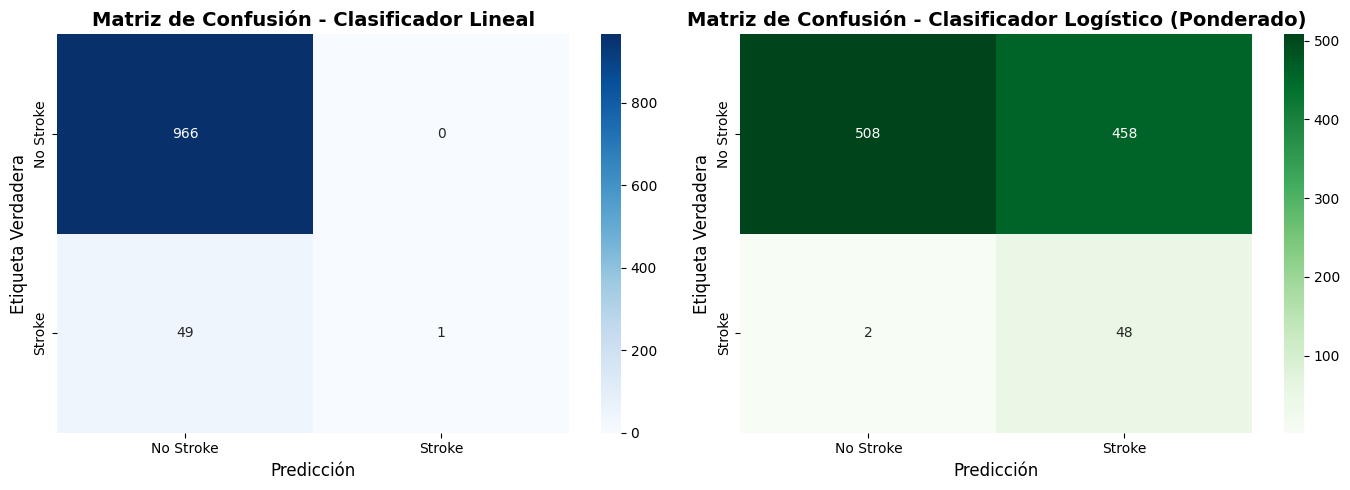

In [56]:
# Matrices de Confusión
cm_lin = confusion_matrix(y_true, y_pred_lin_bin) # matriz de confusión para el clasificador lineal
cm_log = confusion_matrix(y_true, y_pred_log_bin) # matriz de confusión para el clasificador logístico

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz de confusión - Clasificador Lineal
sns.heatmap(cm_lin, annot=True, fmt='d', cmap='Blues', cbar=True, ax=axes[0],
            xticklabels=['No Stroke', 'Stroke'], yticklabels=['No Stroke', 'Stroke'])
axes[0].set_title('Matriz de Confusión - Clasificador Lineal', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Etiqueta Verdadera', fontsize=12)
axes[0].set_xlabel('Predicción', fontsize=12)

# Matriz de confusión - Clasificador Logístico (Ponderado)
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Greens', cbar=True, ax=axes[1],
            xticklabels=['No Stroke', 'Stroke'], yticklabels=['No Stroke', 'Stroke'])
axes[1].set_title('Matriz de Confusión - Clasificador Logístico (Ponderado)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Etiqueta Verdadera', fontsize=12)
axes[1].set_xlabel('Predicción', fontsize=12)

plt.tight_layout()
plt.show()

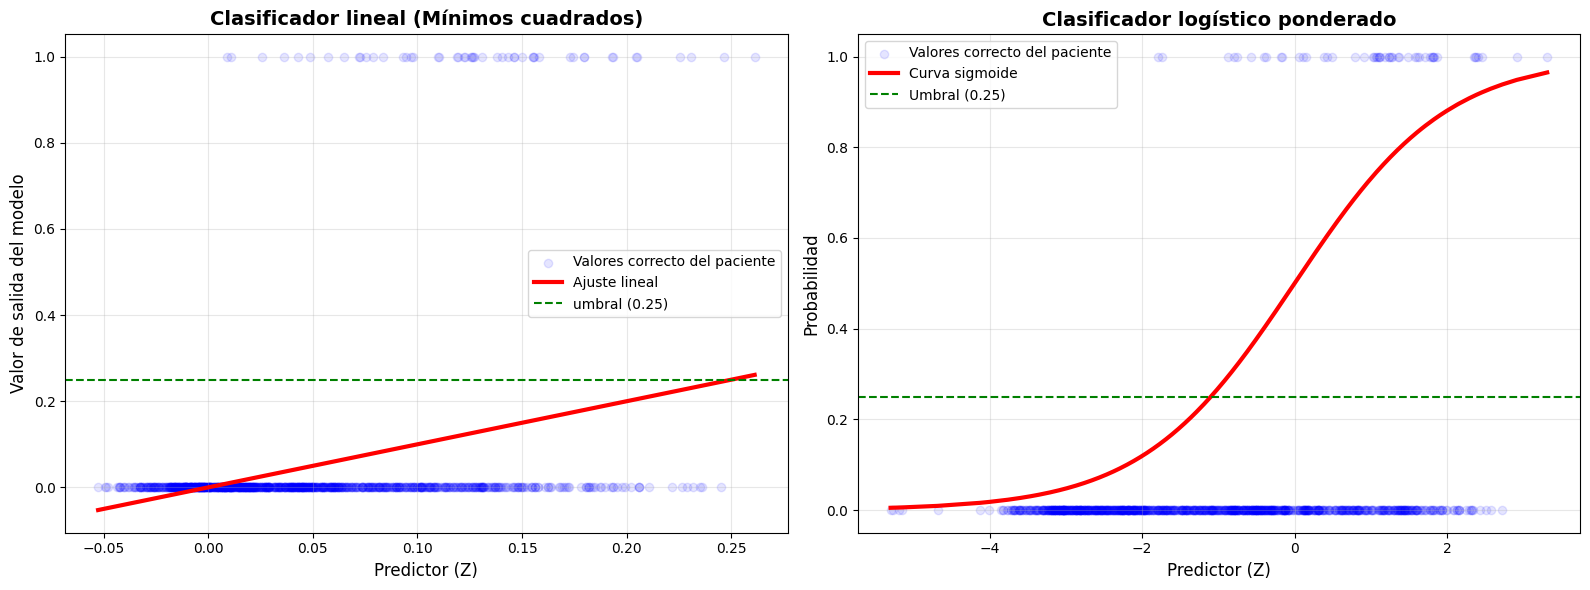

In [57]:
# Visualización
z_lin = jnp.dot(X_test, lin_model.theta).flatten() # z_lin representa la combinación lineal para el modelo lineal
z_log = jnp.dot(X_test, log_model.theta).flatten() # z_log es para la combinacion lineal del modelo logistico, esto es necesario para poder graficar la relación entre el puntaje crudo (Z) y las predicciones del modelo, tanto para el modelo lineal como para el modelo logístico, esto nos permite visualizar cómo el modelo transforma los puntajes crudos en predicciones y cómo se relacionan con los valores reales de la clase objetivo (stroke = 0 o 1). Al ordenar z_lin y z_log, podemos trazar las curvas de predicción de ambos modelos de manera ordenada, lo que facilita la comparación visual entre ellos y con los datos reales.

sort_idx_lin = jnp.argsort(z_lin) # obtenemos los indices que ordenan z_lin de menor a mayor, necesario para  ordenar las predicciones del modelo lineal de acuerdo con los puntajes crudos, lo que nos permite trazar una curva de predicción ordenada en el gráfico, facilitando la visualización de cómo el modelo lineal transforma los puntajes crudos en predicciones y cómo se relacionan con los valores reales de la clase objetivo (stroke = 0 o 1).
z_lin_sorted = z_lin[sort_idx_lin] # ordenamos
y_pred_lin_sorted = z_lin_sorted

# lo mismo para el modelo logístico
sort_idx_log = jnp.argsort(z_log)
z_log_sorted = z_log[sort_idx_log]
y_pred_log_sorted = 1.0 / (1.0 + jnp.exp(-z_log_sorted)) # acá es la función a graficar, de la función de activación sigmoide

fig, axes = plt.subplots(1, 2, figsize=(16, 6)) # tamaño de 16 de ancho y 6 de alto, con 1 fila y 2 columnas para los subplots

# Gráfica lineal
axes[0].scatter(z_lin, y_true, color='blue', alpha=0.1, label='Valores correcto del paciente') # graficamos los puntos reales de los pacientes, con alpha=0.1 para hacerlos semitransparentes y evitar que se sobrecargue el gráfico
axes[0].plot(z_lin_sorted, y_pred_lin_sorted, color='red', linewidth=3, label='Ajuste lineal') # graficamos la línea de predicción del modelo lineal, con color rojo y un grosor de línea de 3 para que sea más visible, esta línea representa cómo el modelo lineal transforma los puntajes crudos (Z) en predicciones continuas
axes[0].axhline(processor.umbral, color='green', linestyle='--', label=f'umbral ({processor.umbral})')
axes[0].set_title('Clasificador lineal (Mínimos cuadrados)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Predictor (Z)', fontsize=12)
axes[0].set_ylabel('Valor de salida del modelo', fontsize=12)
axes[0].legend()
axes[0].grid(alpha=0.3)

# --- Logistic Subplot ---
axes[1].scatter(z_log, y_true, color='blue', alpha=0.1, label='Valores correcto del paciente')
axes[1].plot(z_log_sorted, y_pred_log_sorted, color='red', linewidth=3, label='Curva sigmoide')

axes[1].axhline(processor.umbral, color='green', linestyle='--', label=f'Umbral ({processor.umbral})')
axes[1].set_title('Clasificador logístico ponderado', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Predictor (Z)', fontsize=12)
axes[1].set_ylabel('Probabilidad', fontsize=12)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()